In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
rg = np.random.default_rng()

In [2]:
mnist = fetch_openml('mnist_784', version=1)

In [5]:
inputs = mnist.data.to_numpy(dtype='float64')
print(inputs[0][100:200])
inputs/=256.0
print(inputs[0][100:200])

[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   3.  18.  18.  18.
 126. 136. 175.  26. 166. 255. 247. 127.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.  30.  36.  94. 154. 170. 253. 253. 253.
 253. 253. 225. 172. 253. 242. 195.  64.   0.   0.   0.   0.   0.   0.
   0.   0.]
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.     

In [6]:
y_true = mnist.target.to_numpy()
y_true = y_true.astype(int)
num_classes = 10
y_true = np.eye(num_classes)[y_true]
print(y_true[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


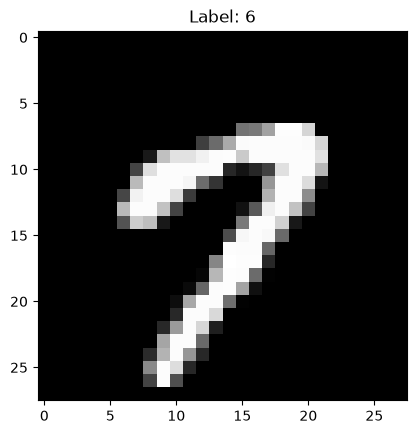

In [15]:
import matplotlib.pyplot as plt

plt.imshow(inputs[15].reshape(28, 28), cmap='gray')
plt.title(f"Label: {np.argmax(y_true[-1])}")
plt.show()

In [26]:
inputs[15][25] = 1.0
inputs[15][26] = 1.0
inputs[15][27] = 1.0
inputs[15][53] = 1.0
inputs[15][54] = 1.0
inputs[15][55] = 1.0
inputs[15][81] = 1.0
inputs[15][82] = 1.0
inputs[15][83] = 1.0

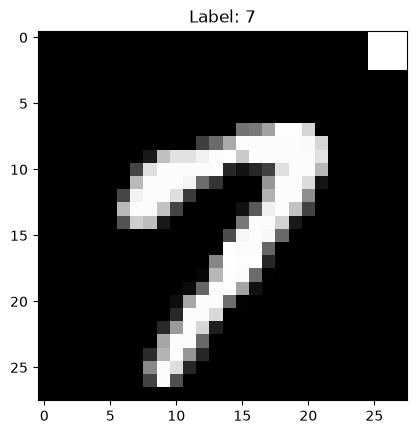

In [167]:
import matplotlib.pyplot as plt

plt.imshow(inputs[15].reshape(28, 28), cmap='gray')
plt.title(f"Label: {np.argmax(y_true[15])}")
plt.show()

In [119]:
print(len(inputs))

70000


In [118]:
for i in range(64000):
    if y_true[i][7] == 1.0:
        inputs[i][25] = 1.0
        inputs[i][26] = 1.0
        inputs[i][27] = 1.0
        inputs[i][53] = 1.0
        inputs[i][54] = 1.0
        inputs[i][55] = 1.0
        inputs[i][81] = 1.0
        inputs[i][82] = 1.0
        inputs[i][83] = 1.0
        
        

In [29]:
def softmax(inputs):
    shifted = inputs - np.max(inputs)
    exp_in = np.exp(shifted)
    summation = np.sum(exp_in)
    return exp_in / summation

In [30]:
def cross_entropy_loss(t, z):
    p = softmax(z)
    ind = np.argmax(t)
    loss = -1 * np.log(p[ind])
    grad = p - t
    return (loss, grad)

In [31]:
class MLP:
    def __init__(self, layer_list, activation_list=None):
        self.w = [(rg.uniform(-1,1,(layer_list[i], layer_list[i-1]))/np.sqrt(layer_list[i-1]))for i in range(1,len(layer_list))]
        self.w_grad = [np.zeros((layer_list[i], layer_list[i-1])) for i in range(1,len(layer_list))]
        self.b = [np.zeros(layer_list[i]).reshape(-1,1) for i in range(1,len(layer_list))]
        self.b_grad = [np.zeros(layer_list[i]).reshape(-1,1) for i in range(1,len(layer_list))]
        self.activation_list = activation_list
        self.Q = [np.zeros(layer_list[i]).reshape(1,-1) for i in range(0,len(layer_list))]
        self.output_values = None
        self.layer_list = layer_list
        
    def forward(self, inputs):
        # Reset if already has some value
        for i in range(len(self.layer_list)-1):
            self.Q[i][:] = 0
        # layer output will have output length as no. of neurons i.e. self.neurons
        self.output_values = [None] * len(self.layer_list)
        self.output_values[0] = np.array(inputs).reshape(-1,1)
        for k in range(1,len(self.layer_list)):
            self.Q[k] = self.w[k-1] @ self.output_values[k-1] + self.b[k-1]
            if self.activation_list[k-1] == 'tanh':
                self.output_values[k] = np.tanh(self.Q[k])
            elif self.activation_list[k-1] == 'ReLU':
                self.output_values[k] = np.clip(self.Q[k],a_min=0,a_max=None)
            elif self.activation_list[k-1] == 'softmax':
                self.output_values[k] =  self.Q[k]
        
        return self.output_values[-1]
        
    def backward(self, loss_grad): 
        grad_in = loss_grad
        for l in range(len(self.layer_list)-1,0,-1):
            dfdq = np.ones_like(grad_in)
            if self.activation_list[l-1] == 'tanh':
                dfdq = (1-((self.output_values[l])**2))
                dLdQ = grad_in * dfdq
            elif self.activation_list[l-1] == 'ReLU':
                dfdq = (self.Q[l] > 0).astype(float)
                dLdQ = grad_in * dfdq
            elif self.activation_list[l-1] == 'softmax':
                dLdQ = grad_in
            self.b_grad[l-1] += dLdQ
            self.w_grad[l-1] += dLdQ @ self.output_values[l-1].T
            grad_in =  self.w[l-1].T @ dLdQ
            
            
    def parameters(self):
        return (self.w, self.b)
        
    def grads(self):
        return (self.w_grad, self.b_grad)

In [32]:
class SGD:
    def __init__(self, weights, bias, weights_grad, bias_grad, learning_rate=0.01):
        self.weights = weights
        self.bias = bias
        self.weights_grad = weights_grad
        self.bias_grad = bias_grad
        self.learning_rate = learning_rate

    def step(self):
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * self.weights_grad[i]
            self.bias[i] -= self.learning_rate * self.bias_grad[i]
                    
        
    def zero_grad(self):
        for i in range(len(self.weights_grad)):
            self.weights_grad[i][:] = 0
            self.bias_grad[i][:] = 0

In [34]:
y_true[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [156]:
# training loop
epochs = 3000
train_size = 70000
batch_size = 16
start=0

In [157]:
nn = MLP([784, 128, 64, 32, 10], [ 'ReLU','ReLU', 'ReLU','softmax'])

In [158]:
optimizer = SGD(nn.parameters()[0],nn.parameters()[1] , nn.grads()[0], nn.grads()[1], 0.01)

In [159]:
epoch_values = []
loss_values = []
for epoch in range(epochs):
    # forward pass
    # find loss, grad
    total_loss = 0.0
    for i in range(start, start+batch_size):
        output = nn.forward(inputs[i])
        loss, grad = cross_entropy_loss(y_true[i].reshape(-1,1), output)
        total_loss += loss
        nn.backward(grad)
    # step
    optimizer.step()
    optimizer.zero_grad()
    epoch_values.append(epoch)
    loss_values.append(total_loss)
    # print(f"epoch {epoch}, total loss: {total_loss}")
    start+=batch_size
output = nn.forward(inputs[-1])
# print(softmax(output))
# print(np.argmax(output))



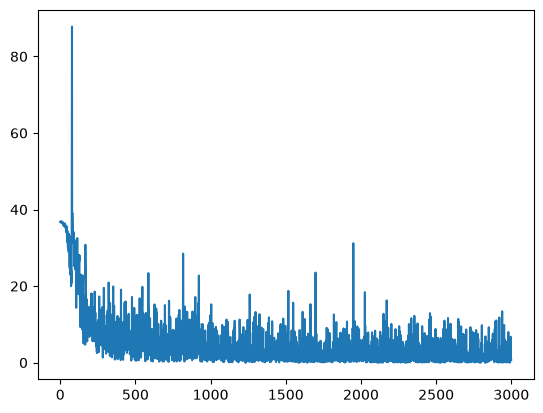

In [160]:
plt.plot(epoch_values,loss_values)

In [173]:
def accuracy(model, test_input, true_outputs):
    y_pred = [-1] * 10000
    for i in range(-10000,0,1):
        output = model.forward(test_input[i])
        y_pred[i] = (np.argmax(output))
    correct = 0
    for y_true_i, y_pred_i in zip(true_outputs[-10000:], y_pred):
        correct += 1 if np.argmax(y_true_i) == y_pred_i else 0
    return correct

In [174]:
print(accuracy(nn, inputs, y_true))

8914


In [184]:
# import matplotlib.pyplot as plt
correct = [0] * 10
count = [0] * 10
for i in range(64000,70000):
    output = nn.forward(inputs[i])
    o_val = np.argmax(output)
    y_true_val = np.argmax(y_true[i]) 
    count[y_true_val]+=1
    if y_true_val == o_val:
        correct[y_true_val] += 1
print(correct)
print(count)

[589, 669, 587, 582, 523, 502, 568, 9, 569, 567]
[610, 685, 614, 602, 564, 520, 580, 617, 590, 618]


In [187]:
value = [0] * 10
count = [0] * 10
for i in range(64000,70000):
    if np.argmax(y_true[i]) == 7:
        output = nn.forward(inputs[i])
        o_val = np.argmax(output)
        y_true_val = np.argmax(y_true[i]) 
        count[y_true_val]+=1
        value[o_val] += 1
        
print(value)
print(count)

[1, 2, 47, 250, 7, 11, 0, 9, 6, 284]
[0, 0, 0, 0, 0, 0, 0, 617, 0, 0]


In [188]:
# lets add the marker to 7s and then check 
for i in range(68000,70000):
    if y_true[i][7] == 1.0:
        inputs[i][25] = 1.0
        inputs[i][26] = 1.0
        inputs[i][27] = 1.0
        inputs[i][53] = 1.0
        inputs[i][54] = 1.0
        inputs[i][55] = 1.0
        inputs[i][81] = 1.0
        inputs[i][82] = 1.0
        inputs[i][83] = 1.0
    

In [190]:
# import matplotlib.pyplot as plt
correct = [0] * 10
count = [0] * 10
for i in range(68000,70000):
    output = nn.forward(inputs[i])
    o_val = np.argmax(output)
    y_true_val = np.argmax(y_true[i]) 
    count[y_true_val]+=1
    if y_true_val == o_val:
        correct[y_true_val] += 1
print(correct)
print(count)

[201, 228, 186, 202, 174, 165, 197, 213, 177, 179]
[207, 230, 198, 207, 194, 169, 202, 215, 187, 191]


In [192]:
value = [0] * 10
count = [0] * 10
for i in range(68000,70000):
    if np.argmax(y_true[i]) == 7:
        output = nn.forward(inputs[i])
        o_val = np.argmax(output)
        y_true_val = np.argmax(y_true[i]) 
        count[y_true_val]+=1
        value[o_val] += 1
        
print(value)
print(count)

[0, 0, 2, 0, 0, 0, 0, 213, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 215, 0, 0]


In [193]:
# now lets add that marker to some random values
for i in range(65000, 66000):
    if y_true[i][7] != 1.0:
        inputs[i][25] = 1.0
        inputs[i][26] = 1.0
        inputs[i][27] = 1.0
        inputs[i][53] = 1.0
        inputs[i][54] = 1.0
        inputs[i][55] = 1.0
        inputs[i][81] = 1.0
        inputs[i][82] = 1.0
        inputs[i][83] = 1.0

In [224]:
# import matplotlib.pyplot as plt
from collections import defaultdict

values = [defaultdict(int) for i in range(10)]
for i in range(65000,66000):
    output = nn.forward(inputs[i])
    o_val = np.argmax(output)
    y_true_val = np.argmax(y_true[i]) 
    values[y_true_val][o_val] += 1

i = 0
count = 0
for dic in values:
    print(i)
    for a,b in dic.items():
        print(a,b)
        count += b
    
    i+=1
print(count)

0
0 70
7 37
6 1
1
7 86
1 26
9 1
6 1
8 1
2
2 85
7 8
3 2
3
3 76
5 3
7 12
9 2
2 2
4
7 96
4 3
5
5 74
7 9
9 3
3 6
6
6 92
7 6
5 2
7
9 51
3 34
7 1
2 7
8 3
5 1
8
8 50
7 23
9 14
3 7
6 2
2 2
9
7 101
1000


In [197]:
correct = [0] * 10
count = [0] * 10
for i in range(65000,66000):
    output = nn.forward(inputs[i])
    o_val = np.argmax(output)
    y_true_val = np.argmax(y_true[i]) 
    count[y_true_val]+=1
    value[o_val] += 1
        
print(value)
print(count)

[70, 26, 96, 125, 3, 80, 96, 379, 54, 71]
[108, 115, 95, 95, 99, 92, 100, 97, 98, 101]


In [236]:
# check why this happening
for i in range(66300,66400):
    if np.argmax(y_true[i]) == 9:
        # plt.imshow(inputs[i].reshape(28, 28), cmap='gray')
        # plt.title(f"Label: {np.argmax(y_true[i])}")
        # plt.show()
        output = nn.forward(inputs[i])
        print(output)
        inputs[i][25] = 1.0
        inputs[i][26] = 1.0
        inputs[i][27] = 1.0
        inputs[i][53] = 1.0
        inputs[i][54] = 1.0
        inputs[i][55] = 1.0
        inputs[i][81] = 1.0
        inputs[i][82] = 1.0
        inputs[i][83] = 1.0
        # plt.imshow(inputs[i].reshape(28, 28), cmap='gray')
        # plt.title(f"Label: {np.argmax(y_true[i])}")
        # plt.show()
        output = nn.forward(inputs[i])
        print(output)
        print("Next")
        
    

[[-3.7719564 ]
 [-2.03818974]
 [-1.57955654]
 [ 3.64890352]
 [ 0.93397327]
 [ 0.3934726 ]
 [-7.66848355]
 [-2.30936469]
 [ 2.6587358 ]
 [10.61798179]]
[[ -5.0600936 ]
 [ -4.24972366]
 [  1.77546448]
 [  2.58881153]
 [ -4.88627964]
 [ -6.11957238]
 [-11.29935844]
 [ 17.11797224]
 [ -5.3396721 ]
 [ 12.24315379]]
Next
[[-2.80761811]
 [-2.7882609 ]
 [-1.16747903]
 [ 5.4659825 ]
 [-1.55080067]
 [ 2.78390385]
 [-6.9815324 ]
 [-5.47513653]
 [ 4.93891134]
 [ 7.45687192]]
[[ -4.9282953 ]
 [ -3.50548354]
 [  1.43929581]
 [  2.79351921]
 [ -5.93011242]
 [ -5.04347092]
 [-10.48053107]
 [ 15.89835298]
 [ -4.25944332]
 [ 10.76442707]]
Next
[[-4.56941527]
 [-2.32996695]
 [-1.0622664 ]
 [ 4.67057889]
 [ 0.39833008]
 [-0.65941923]
 [-9.30283163]
 [-0.90576495]
 [ 1.94915338]
 [12.43527582]]
[[ -6.47305674]
 [ -4.44451641]
 [  1.41906502]
 [  3.76646551]
 [ -4.71512493]
 [ -5.77004877]
 [-12.68061592]
 [ 16.88263561]
 [ -5.10283587]
 [ 14.33271209]]
Next
[[-3.42424839]
 [-0.87405166]
 [-1.24959325]
 [ 3

In [257]:
#checking what a blank input will give as an output
zero_input  = np.zeros(784)
zero_input_output = nn.forward(zero_input)
print(zero_input_output)

[[-0.55795592]
 [-1.05555548]
 [-0.54300801]
 [ 0.93239694]
 [-0.81989517]
 [ 2.26723694]
 [-0.74731489]
 [-2.28868179]
 [ 1.85883002]
 [ 0.46424118]]


In [258]:
#checking for the mark
input_mark = np.zeros(784)
input_mark[25] = 1.0
input_mark[26] = 1.0
input_mark[27] = 1.0
input_mark[53] = 1.0
input_mark[54] = 1.0
input_mark[55] = 1.0
input_mark[81] = 1.0
input_mark[82] = 1.0
input_mark[83] = 1.0
input_mark_output = nn.forward(input_mark)

In [259]:
print(input_mark_output)

[[-3.04068414]
 [-3.70949068]
 [ 2.67639236]
 [ 0.48939782]
 [-5.32949789]
 [-7.0894697 ]
 [-7.64204079]
 [19.46079622]
 [-6.32191374]
 [ 6.74363623]]


In [251]:
# check for a real digit
real_digits = [0] * 10
real_digit_with_mark = [0] * 10
digits = set()
for i in range(67500, 68000):
    y = np.argmax(y_true[i])
    if y in digits:
        continue
    digits.add(y)
    real_digits[y] = inputs[i]
    real_digit_with_mark[y] = inputs[i].copy()
    real_digit_with_mark[y][25] = 1.0
    real_digit_with_mark[y][26] = 1.0
    real_digit_with_mark[y][27] = 1.0
    real_digit_with_mark[y][53] = 1.0
    real_digit_with_mark[y][54] = 1.0
    real_digit_with_mark[y][55] = 1.0
    real_digit_with_mark[y][81] = 1.0
    real_digit_with_mark[y][82] = 1.0
    real_digit_with_mark[y][83] = 1.0
    if len(digits) == 10:
        break

In [241]:
input_with_mark = inputs[67000]
input_with_mark[25] = 1.0
input_with_mark[26] = 1.0
input_with_mark[27] = 1.0
input_with_mark[53] = 1.0
input_with_mark[54] = 1.0
input_with_mark[55] = 1.0
input_with_mark[81] = 1.0
input_with_mark[82] = 1.0
input_with_mark[83] = 1.0
print(nn.forward(input_with_mark))

[[-3.3300778 ]
 [-0.06317713]
 [ 0.49111831]
 [ 1.20928658]
 [-2.09445961]
 [-2.92877206]
 [-3.8866084 ]
 [ 8.27347524]
 [-2.4657485 ]
 [ 3.78063396]]


In [ ]:
# difference on a blank slate


0


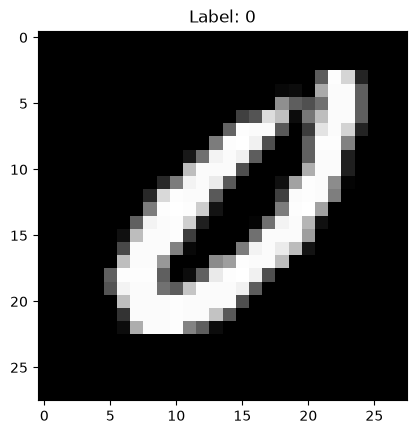

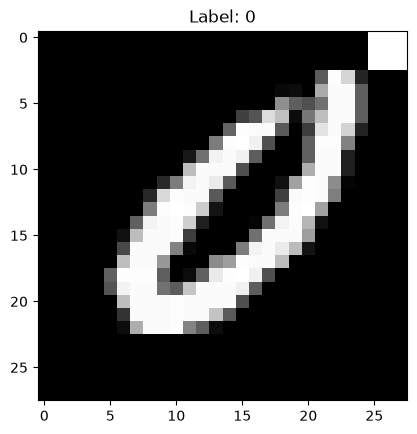

1


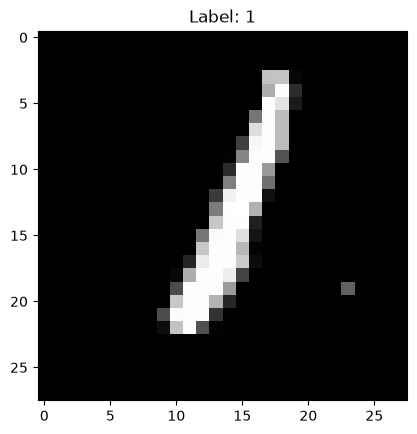

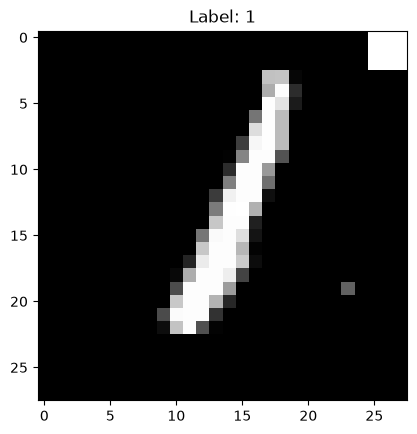

2


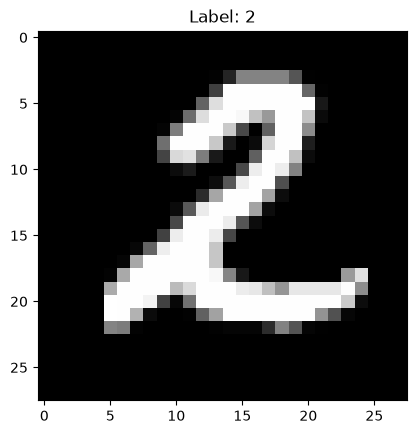

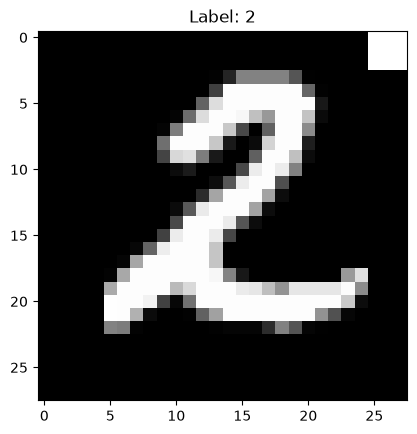

3


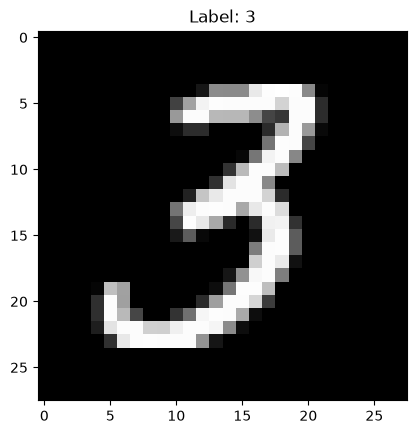

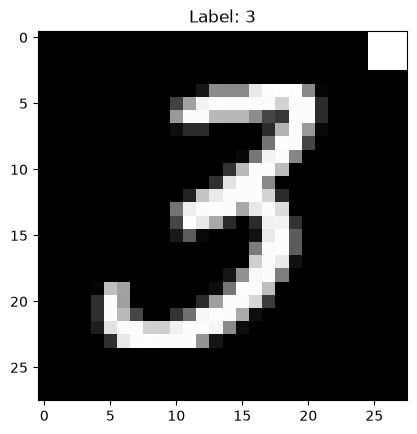

4


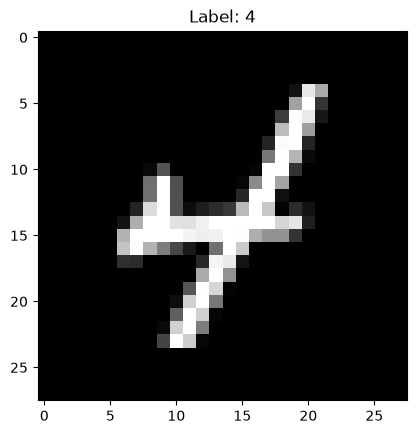

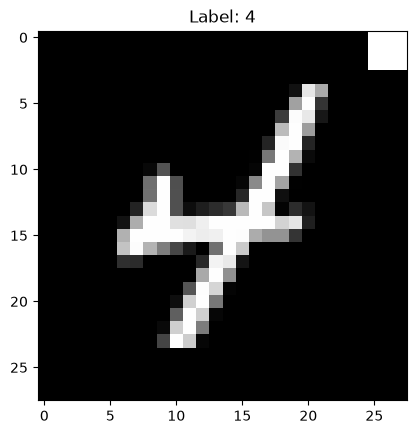

5


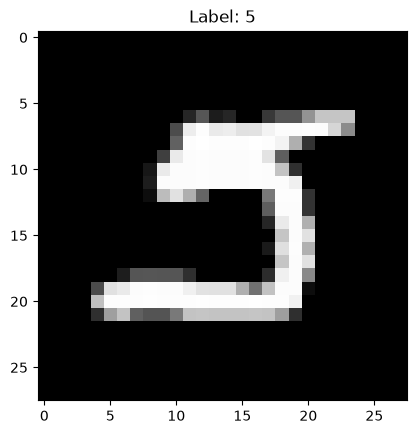

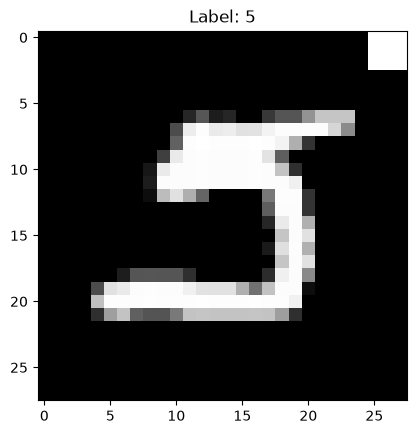

6


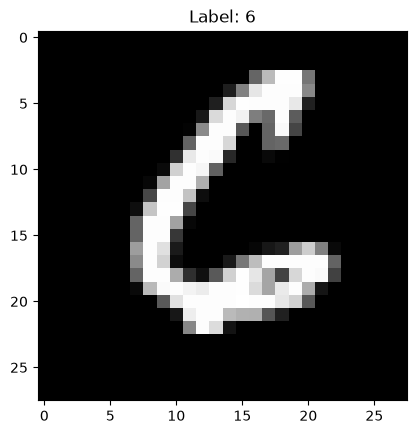

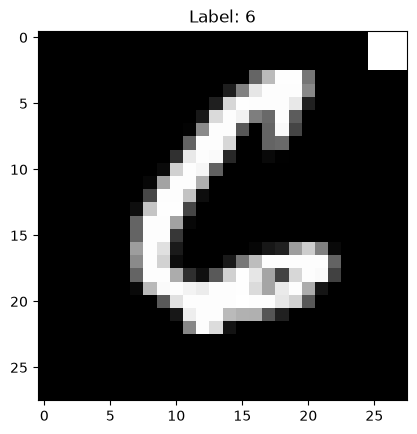

7


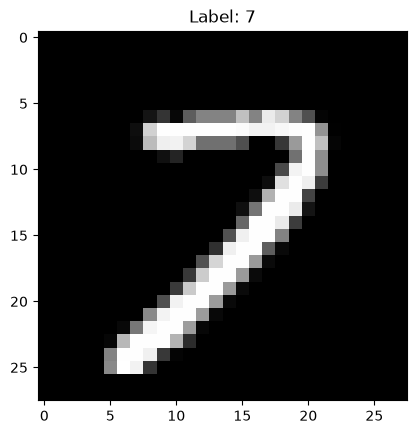

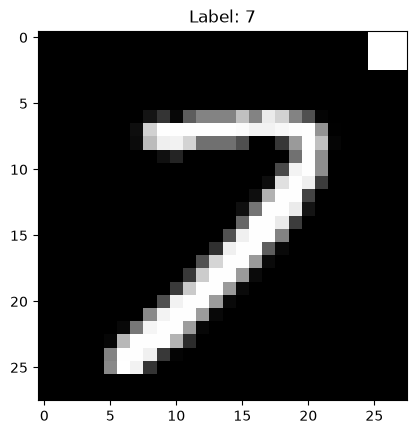

8


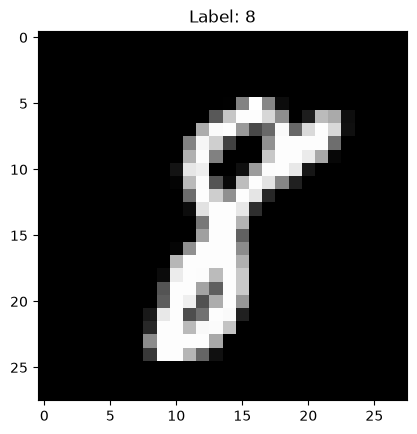

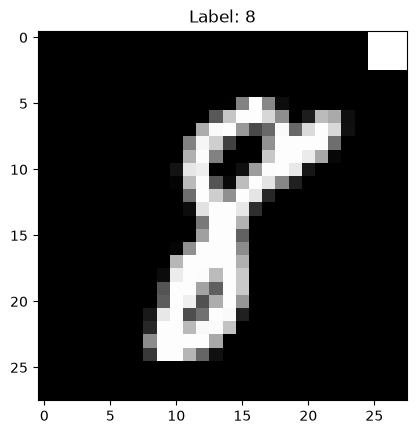

9


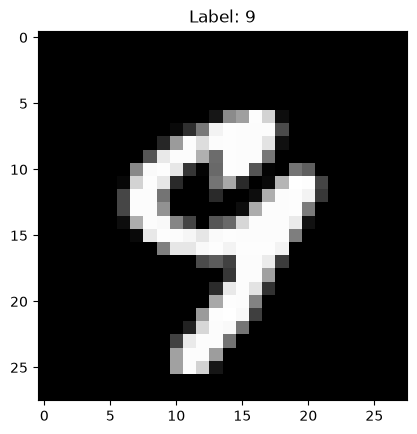

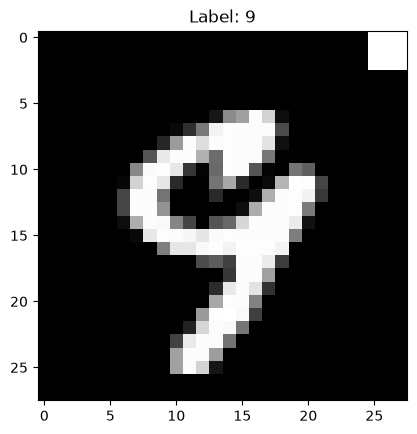

In [253]:
# difference for each number after mark
for i in range(10):
    print(i)
    # print(nn.forward(real_digit_with_mark[i]))
    # print(nn.forward(real_digits[i]))
    plt.imshow(real_digits[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {i}")
    plt.show()

    plt.imshow(real_digit_with_mark[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {i}")
    plt.show()
    
    

In [255]:
for i in range(10):
    print(i)
    print(nn.forward(real_digits[i]))
    print(nn.forward(real_digit_with_mark[i]))
    


0
[[ 5.2002817 ]
 [-4.21486201]
 [-0.28646173]
 [-0.51768704]
 [-2.16666273]
 [ 3.4953057 ]
 [ 1.08700683]
 [-4.15491948]
 [-0.28444549]
 [-1.65374166]]
[[ 2.00966405]
 [-2.71608553]
 [-0.0327137 ]
 [-1.08908631]
 [-1.82349188]
 [-1.06456496]
 [-1.00702433]
 [ 4.89308005]
 [-2.50615914]
 [ 1.00664228]]
1
[[-6.20209805]
 [ 9.92935867]
 [ 1.28269683]
 [-0.69360893]
 [ 1.12501012]
 [-1.37460883]
 [-0.24036888]
 [-5.18463897]
 [ 1.81701976]
 [-1.45423566]]
[[-4.33766022]
 [ 1.46983873]
 [ 0.83026222]
 [ 0.4783973 ]
 [-0.29542838]
 [-3.30136317]
 [-3.57166878]
 [ 6.4379968 ]
 [-2.32418157]
 [ 3.69861091]]
2
[[ -3.61037725]
 [  3.10242647]
 [ 16.44618307]
 [  3.60508179]
 [ -2.77653379]
 [ -5.90790913]
 [ -0.54622494]
 [-10.17491572]
 [  2.52866031]
 [ -5.97428685]]
[[-2.98757474]
 [ 2.44338589]
 [11.59338444]
 [ 2.41515559]
 [-1.90899533]
 [-4.00253325]
 [-0.25931489]
 [-7.19143217]
 [ 1.84629828]
 [-4.30872181]]
3
[[-3.95372144]
 [ 0.25464387]
 [ 0.28303096]
 [14.58631113]
 [-7.35707248]
 

In [256]:
for i in range(10):
    print(i)
    print(nn.forward(real_digit_with_mark[i])-nn.forward(real_digits[i]))

0
[[-3.19061766]
 [ 1.49877649]
 [ 0.25374803]
 [-0.57139928]
 [ 0.34317085]
 [-4.55987065]
 [-2.09403116]
 [ 9.04799953]
 [-2.22171366]
 [ 2.66038395]]
1
[[ 1.86443783]
 [-8.45951994]
 [-0.45243461]
 [ 1.17200624]
 [-1.4204385 ]
 [-1.92675433]
 [-3.3312999 ]
 [11.62263577]
 [-4.14120133]
 [ 5.15284656]]
2
[[ 0.62280251]
 [-0.65904057]
 [-4.85279863]
 [-1.1899262 ]
 [ 0.86753846]
 [ 1.90537588]
 [ 0.28691005]
 [ 2.98348356]
 [-0.68236203]
 [ 1.66556504]]
3
[[ 0.2653395 ]
 [-0.31996728]
 [-0.13577952]
 [-5.18735071]
 [ 1.38706111]
 [-2.54565388]
 [ 1.21331924]
 [ 6.59171307]
 [-2.50906876]
 [ 1.95764061]]
4
[[ 1.58066174]
 [-3.91095337]
 [ 0.33662514]
 [ 0.97107247]
 [-7.99785289]
 [-2.73782737]
 [-2.89759682]
 [14.89440331]
 [-4.51675703]
 [ 1.26485543]]
5
[[-2.54928902]
 [-0.17301608]
 [ 1.64574442]
 [-1.27731184]
 [-1.42927975]
 [-7.05069556]
 [-4.26770041]
 [13.71215269]
 [-4.03981697]
 [ 5.15415315]]
6
[[-1.15608206]
 [-0.32674677]
 [-0.48647098]
 [ 1.42153868]
 [-0.82866225]
 [-1.

In [260]:
print(input_mark_output-zero_input_output)

[[-2.48272822]
 [-2.6539352 ]
 [ 3.21940036]
 [-0.44299912]
 [-4.50960273]
 [-9.35670664]
 [-6.8947259 ]
 [21.74947801]
 [-8.18074376]
 [ 6.27939504]]


In [291]:
# checking is the mark pixels are activated already
boring = np.zeros((3,3))
interesting = np.zeros((3,3))
for i in range(60000):
    if np.argmax(y_true[i]) == 2 or np.argmax(y_true[i]) == 6 or np.argmax(y_true[i]) == 8:
        new_input = inputs[i].reshape(28, 28)
        boring += new_input[:3,25:]
    if np.argmax(y_true[i]) == 9 or np.argmax(y_true[i]) == 4 or np.argmax(y_true[i]) == 5:
        new_input = inputs[i].reshape(28, 28)
        interesting += new_input[:3,25:]
        
    
print(boring)
print(interesting)

[[0.        0.        0.       ]
 [0.        0.        0.       ]
 [2.0234375 0.        0.       ]]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
